In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from dataprocess import process, vprocess
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

# Load the training and testing data
train_input = np.load('archive\\data(processed)\\train_input.npy')
train_output = np.load('archive\\data(processed)\\train_output.npy')
test_input = np.load('archive\\data(processed)\\test_input.npy')
test_output = np.load('archive\\data(processed)\\test_output.npy')


In [6]:
print("Training input shape: ", train_input.shape)
print("Training output shape: ", train_output.shape)
print("Testing input shape: ", test_input.shape)
print("Testing output shape: ", test_output.shape)

Training input shape:  (570, 256, 256)
Training output shape:  (570, 256, 256)
Testing input shape:  (150, 256, 256)
Testing output shape:  (150, 256, 256)


Visualizing Training Data


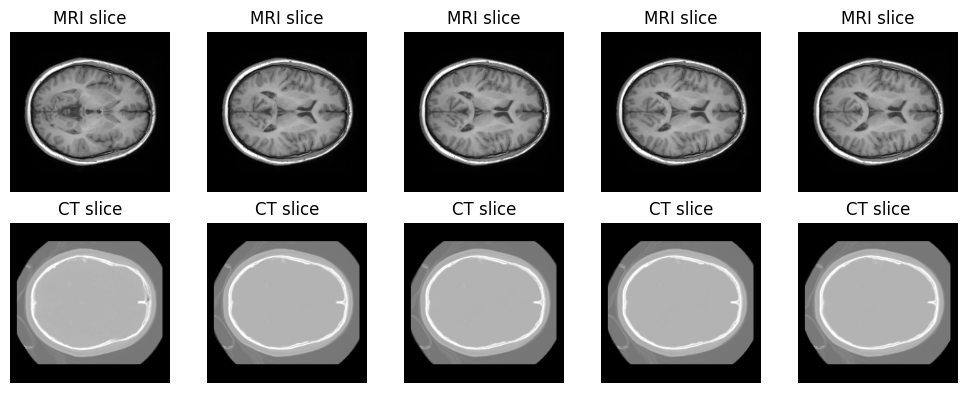

Visualizing Testing Data


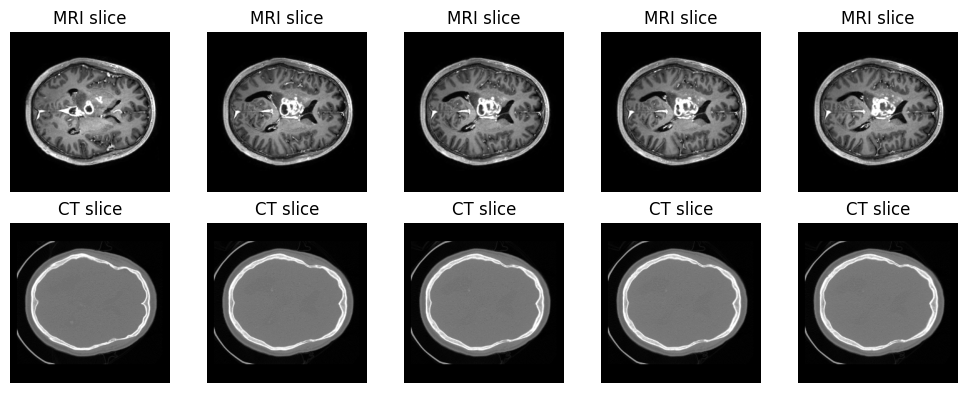

In [17]:

# Function to visualize the data
def visualize_data(input_images, output_images, num_samples=5):
    plt.figure(figsize=(10, 4))
    for i in range(num_samples):
        # MRI images
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(input_images[i], cmap='gray')
        plt.title("MRI slice")
        plt.axis('off')
        
        # CT images
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(output_images[i], cmap='gray')
        plt.title("CT slice")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize some of the training data
print("Visualizing Training Data")
visualize_data(train_input, train_output)

# Visualize some of the testing data
print("Visualizing Testing Data")
visualize_data(test_input, test_output)


In [2]:
class AttentionBlock(nn.Module):
    def __init__(self, in_channels, gating_channels, inter_channels):
        super(AttentionBlock, self).__init__()
        # W_g should transform the gating signal to the intermediate channel size
        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_channels)
        )

        # W_x should transform the skip connection to the intermediate channel size
        self.W_x = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_channels)
        )

        # Psi is a convolution that reduces the channel dimension to 1 for the sigmoid activation
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        
        # Return the attended feature map; the sigmoid activation will serve as an attention mask
        return x * psi
    

# Integrate AttentionBlock into UNetUp
class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super(UNetUp, self).__init__()
        # The layer to upsample the feature map
        self.up = nn.ConvTranspose2d(in_size, out_size, 3, stride=2, padding=1, output_padding=1)
        
        self.conv = nn.Sequential(
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True)
        )
        
        if dropout:
            self.conv.add_module("dropout", nn.Dropout(dropout))

        # Instantiate the attention block with correct channel sizes
        self.attention = AttentionBlock(out_size, out_size, out_size // 2)

    def forward(self, x, skip_input):
        x = self.up(x)
        x = self.conv(x)
        # Apply attention to the concatenated skip connection
        skip_input = self.attention(skip_input, x)
        x = torch.cat((x, skip_input), 1)  # Concatenate along the channel dimension
        return x
    
    

class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 3, stride=2, padding=1)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)
    
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(GeneratorUNet, self).__init__()

        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        # Bottom layer
        self.down6 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 256)
        self.up4 = UNetUp(512, 128)
        self.up5 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        u1 = self.up1(d6, d5)
        u2 = self.up2(u1, d4)
        u3 = self.up3(u2, d3)
        u4 = self.up4(u3, d2)
        u5 = self.up5(u4, d1)

        return self.final(u5)



In [3]:
import torch
from torch import nn
from torchviz import make_dot

# Assuming your GeneratorUNet and associated classes are defined in the same script

# Create an instance of the generator model
model = GeneratorUNet(in_channels=1, out_channels=1)

# Generate a dummy input according to the input dimensions expected by the model
dummy_input = torch.randn(1, 1, 256, 256)

# Perform a forward pass to get the output
output = model(dummy_input)

# Create a visualization of the model
dot = make_dot(output, params=dict(model.named_parameters()))

# Render the visualization
dot.render('generator_model_visualization_v3', format='png', cleanup=True)

#Display the visualization
#dot.view()

# This will save the visualization as 'generator_model_visualization.png' in the current directory

'generator_model_visualization_v3.png'

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # input is 256x256
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # Global average pooling

        self.output = nn.Sequential(
            # This layer now expects a flattened [batch_size, 512] input
            nn.Conv2d(512, 1, kernel_size=1),  # Adjusted kernel size to 1
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)  # Flatten
        out = self.output(out.view(out.size(0), 512, 1, 1))  # Reshape for final conv
        return out.view(-1, 1)  # Reshape to [batch_size, 1]

In [5]:
# Instantiate your model
discriminator = Discriminator()

# Generate a dummy input according to the input dimensions expected by the model
dummy_input = torch.randn(1, 1, 256, 256)

# Perform a forward pass to get the output
output = discriminator(dummy_input)

# Create a visualization of the model
dot = make_dot(output, params=dict(discriminator.named_parameters()))

# Render the visualization and save to file
dot.render('discriminator_model_visualization_v3', format='png', cleanup=True)

'discriminator_model_visualization_v3.png'

In [20]:
import torch.optim as optim
import torch.nn as nn
from torchvision.models import vgg19

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Instantiate the generator and discriminator
generator = GeneratorUNet().to(device)
discriminator = Discriminator().to(device)

# Loss function for the adversarial aspect
adversarial_loss = nn.BCELoss().to(device)

# Content (or feature) loss function, using L1 loss as an example
content_loss = nn.L1Loss().to(device)

# Initialize VGG19 model for content loss and remove the classification head
vgg = vgg19(pretrained=True).features[:36].to(device)
vgg.eval()
for param in vgg.parameters():
    param.requires_grad = False

# Define a function to compute content loss using VGG19 features
def compute_content_loss(gen_features, real_features):
    return content_loss(gen_features, real_features)

# Optimizers for the generator and discriminator
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


c:\Users\raman\anaconda3\envs\mrict\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


c:\Users\raman\anaconda3\envs\mrict\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\raman\anaconda3\envs\mrict\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [21]:
from torch.utils.data import TensorDataset, DataLoader
import torch

# Assuming train_input and train_output are your numpy arrays
# First, convert them to torch tensors
train_input_tensor = torch.Tensor(train_input).unsqueeze(1)  # Add channel dimension
train_output_tensor = torch.Tensor(train_output).unsqueeze(1)  # Add channel dimension

# Create a TensorDataset
train_dataset = TensorDataset(train_input_tensor, train_output_tensor)

# Create a DataLoader
batch_size = 4  # You can adjust the batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [15]:
num_epochs = 50  # You can adjust this
#lambda_pixel = 100  # Weight for the pixel-wise loss relative to the adversarial loss
lambda_content =1

for epoch in range(num_epochs):
    for i, (mris, cts) in enumerate(train_loader):
        
        # Adversarial ground truths
        valid = torch.ones((cts.size(0), 1), requires_grad=False).to(device)
        fake = torch.zeros((cts.size(0), 1), requires_grad=False).to(device)
        
        # Configure input
        real_mris = mris.to(device)
        real_cts = cts.to(device)
        real_cts_rgb = real_cts.repeat(1, 3, 1, 1)  # Repeats the single channel three times along the channel dimension

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # Generate a batch of CT images
        fake_cts = generator(real_mris)
        fake_cts_rgb = fake_cts.repeat(1, 3, 1, 1)  # Repeats the single channel three times along the channel dimension

        # Adversarial loss (how well the generator can fool the discriminator)
        loss_GAN = adversarial_loss(discriminator(fake_cts), valid)

        # Compute content loss using VGG19 features
        gen_features = vgg(fake_cts_rgb)
        real_features = vgg(real_cts_rgb)
        loss_content = compute_content_loss(gen_features, real_features)

        # Total generator loss
        g_loss = loss_GAN + lambda_content * loss_content
        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Measure discriminator's ability to classify real from generated samples
        real_loss = adversarial_loss(discriminator(real_cts), valid)
        fake_loss = adversarial_loss(discriminator(fake_cts.detach()), fake)
        # Total discriminator loss
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # Print some progress every 'n' batches
        if i % 100 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(train_loader)}] [D loss: {d_loss.item()}] [G loss: adv: {loss_GAN.item()}, content: {loss_content.item()}]")

# You might want to save the model and optimizer states at the end of training
torch.save(generator.state_dict(), 'v4generator.pth')
torch.save(discriminator.state_dict(), 'v4discriminator.pth')


[Epoch 0/50] [Batch 0/143] [D loss: 0.5289815664291382] [G loss: adv: 0.937804102897644, content: 0.09447647631168365]
[Epoch 0/50] [Batch 100/143] [D loss: 0.5234566926956177] [G loss: adv: 0.7102215886116028, content: 0.10054048895835876]


KeyboardInterrupt: 

## Load the Model

In [22]:
from collections import OrderedDict

def adjust_state_dict(state_dict, add_module_prefix=True):
    """
    Adjusts the state dict keys by adding or removing the 'module.' prefix.
    
    Args:
    - state_dict (OrderedDict): The state dict to adjust.
    - add_module_prefix (bool): Whether to add the 'module.' prefix. If False, removes it.
    
    Returns:
    - OrderedDict: The adjusted state dict.
    """
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        if add_module_prefix:
            # Add 'module.' if it's not already there
            if not k.startswith('module.'):
                k = 'module.' + k
        else:
            # Remove 'module.' if present
            k = k.replace('module.', '')
        new_state_dict[k] = v
    return new_state_dict

In [25]:
# Assuming the generator model class is already defined and device is set
generator = GeneratorUNet().to(device)

# Load the state dict from file
state_dict = torch.load('v4generator.pth')

# Adjust the state dict by removing 'module.' prefix (set `add_module_prefix=False`)
# If you are loading into a DataParallel model and the saved model didn't use DataParallel,
# set `add_module_prefix=True` instead.
adjusted_state_dict = adjust_state_dict(state_dict, add_module_prefix=False)

# Load the adjusted state dict into your model
generator.load_state_dict(adjusted_state_dict)
generator.eval()  # Set the model to evaluation mode

GeneratorUNet(
  (down1): UNetDown(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (down2): UNetDown(
    (model): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down3): UNetDown(
    (model): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down4): UNetDown(
    (model): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    

## Evaluate the Model

In [26]:
test_input_tensor = torch.Tensor(test_input).unsqueeze(1)  # Add channel dimension
test_output_tensor = torch.Tensor(test_output).unsqueeze(1)  # Add channel dimension

# Create a TensorDataset and DataLoader for test data
test_dataset = TensorDataset(test_input_tensor, test_output_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [27]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from torch.nn.functional import mse_loss

def compute_metrics(real, fake):
    """
    Compute various evaluation metrics.
    
    Parameters:
    - real: torch.Tensor, real images.
    - fake: torch.Tensor, generated images.
    
    Returns:
    A dictionary containing computed metrics.
    """
    real_np = real.detach().cpu().numpy().squeeze()
    fake_np = fake.detach().cpu().numpy().squeeze()
    
    metrics = {}
    
    # Mean Error (ME)
    metrics['ME'] = (fake - real).mean().item()
    
    # Mean Absolute Error (MAE)
    metrics['MAE'] = torch.abs(fake - real).mean().item()
    
    # Mean Square Error (MSE)
    mse = mse_loss(fake, real)
    metrics['MSE'] = mse.item()
    
    # Root Mean Square Error (RMSE)
    metrics['RMSE'] = torch.sqrt(mse).item()
    
    # Peak Signal-to-Noise Ratio (PSNR)
    max_pixel = 1.0
    metrics['PSNR'] = 20 * torch.log10(max_pixel / torch.sqrt(mse)).item()
    
    # Structural Similarity Index (SSIM)
    if real_np.ndim == 2:
        real_np = np.expand_dims(real_np, axis=1)
        fake_np = np.expand_dims(fake_np, axis=1)
    ssim_vals = [ssim(real_np[i], fake_np[i], data_range=real_np[i].max() - real_np[i].min()) for i in range(real_np.shape[0])]
    metrics['SSIM'] = np.mean(ssim_vals)
    
    # Normalized Cross-Correlation (NCC)
    ncc = ((fake - fake.mean()) * (real - real.mean())).mean() / (fake.std() * real.std())
    metrics['NCC'] = ncc.item()

    #Calculate similarity index
    metrics['SI'] = 1 - (2 * mse) / (real + fake).var()

    
    
    return metrics

def evaluate_model_with_metrics(generator, test_loader, device):
    """
    Evaluate the generator model on the test dataset and compute metrics.
    """
    generator.eval()
    total_metrics = {}
    with torch.no_grad():
        for mris, cts in test_loader:
            mris, cts = mris.to(device), cts.to(device)
            fake_cts = generator(mris)
            fake_cts = process(fake_cts,cts)

            
            metrics = compute_metrics(cts, fake_cts)
            
            # Sum up the metrics
            for key, value in metrics.items():
                if key in total_metrics:
                    total_metrics[key] += value
                else:
                    total_metrics[key] = value
                    
    # Average the metrics
    for key in total_metrics.keys():
        total_metrics[key] /= len(test_loader)
        
    return total_metrics

# Example usage
metrics = evaluate_model_with_metrics(generator, test_loader, device)
for metric, value in metrics.items():
    print(f"{metric}: {value}")

ME: -2.4328407654274894e-05
MAE: 0.0797903456251013
MSE: 0.009999465048171752
RMSE: 0.09999723219697924
PSNR: 20.000248481652687
SSIM: 0.24067650534554552
NCC: 0.9427039881566219
SI: 0.9392166843816316


## Visualize Predictions

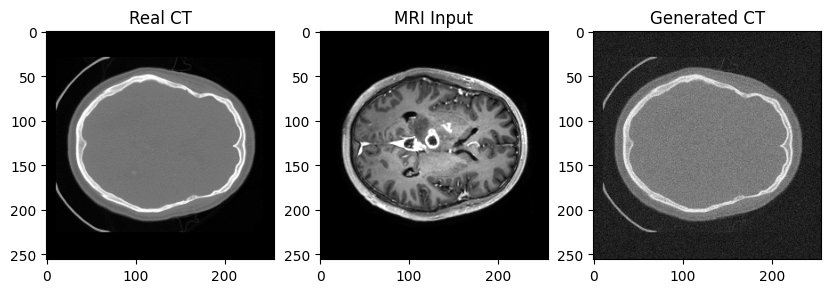

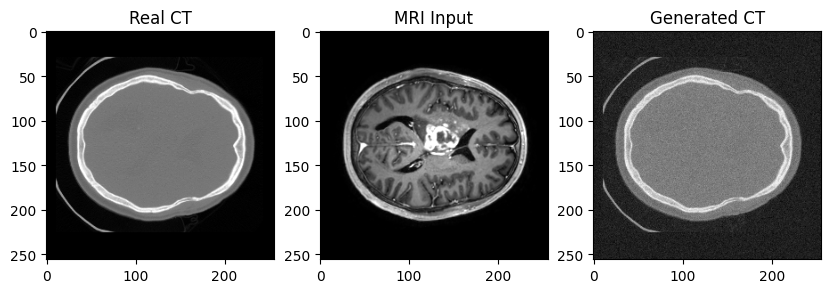

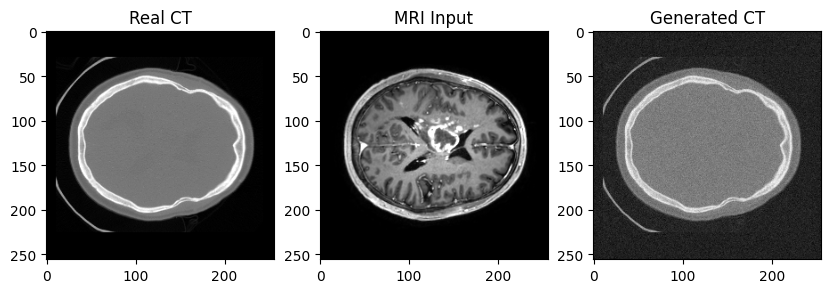

In [28]:
import matplotlib.pyplot as plt

def visualize_predictions(generator, test_loader, device, num_examples=3):
    generator.eval()
    with torch.no_grad():
        for i, (mris, cts) in enumerate(test_loader):
            if i == num_examples:  # Only visualize a few examples
                break
            mris = mris.to(device)
            real_cts = cts.to(device)
            fake_cts = generator(mris)
            fake_cts = vprocess(fake_cts,cts)

            plt.figure(figsize=(10, 4))
            
            plt.subplot(1, 3, 1)
            plt.title("Real CT")
            plt.imshow(real_cts.cpu().squeeze().numpy()[0], cmap='gray')

            plt.subplot(1, 3, 2)
            plt.title("MRI Input")
            plt.imshow(mris.cpu().squeeze().numpy()[0], cmap='gray')
            
            
            
            plt.subplot(1, 3, 3)
            plt.title("Generated CT")
            plt.imshow(fake_cts.cpu().squeeze().numpy()[0], cmap='gray')
            
            plt.show()

# Assuming your model and test_loader are defined and you have a device specified
visualize_predictions(generator, test_loader, device)